Here is the excerpt from the paper that tells us the values of alpha and beta:


We present our ZTF Hubble diagram for the 2629 non-peculiar SNe~Ia that pass our quality cuts in Figure~6. These SNe~Ia have been standardized using the methodology detailed in Ginolin et~al.~(2024), given the SALT2 stretch and color parameters and host local environmental properties (for example, Sullivan et~al.~2010; Rigault et~al.~2020). Following that paper, we adopt the nuisance parameter values $\alpha = -0.16$, $\beta = 3.05$, and $\gamma = 0.145~\mathrm{mag}$ (local-color step).


The standardized distance modulus for each Type~Ia supernova is computed using the Tripp (1998) relation:

The observed distance modulus in the SALT2 framework is given by: 

$
\mu_{\mathrm{obs}} = -2.5 \log_{10}(x_0) + \alpha x_1 - \beta c
$

Link to paper: [doi.org/10.1051/0004-6361/202450943](https://www.aanda.org/articles/aa/full_html/2025/02/aa50943-24/aa50943-24.html)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from scipy.optimize import minimize

# Lets First Do Some Host Galaxy Quality Cuts on Our Sample #

Judging from the following 

In [2]:
# Read the following file:

df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop.csv")


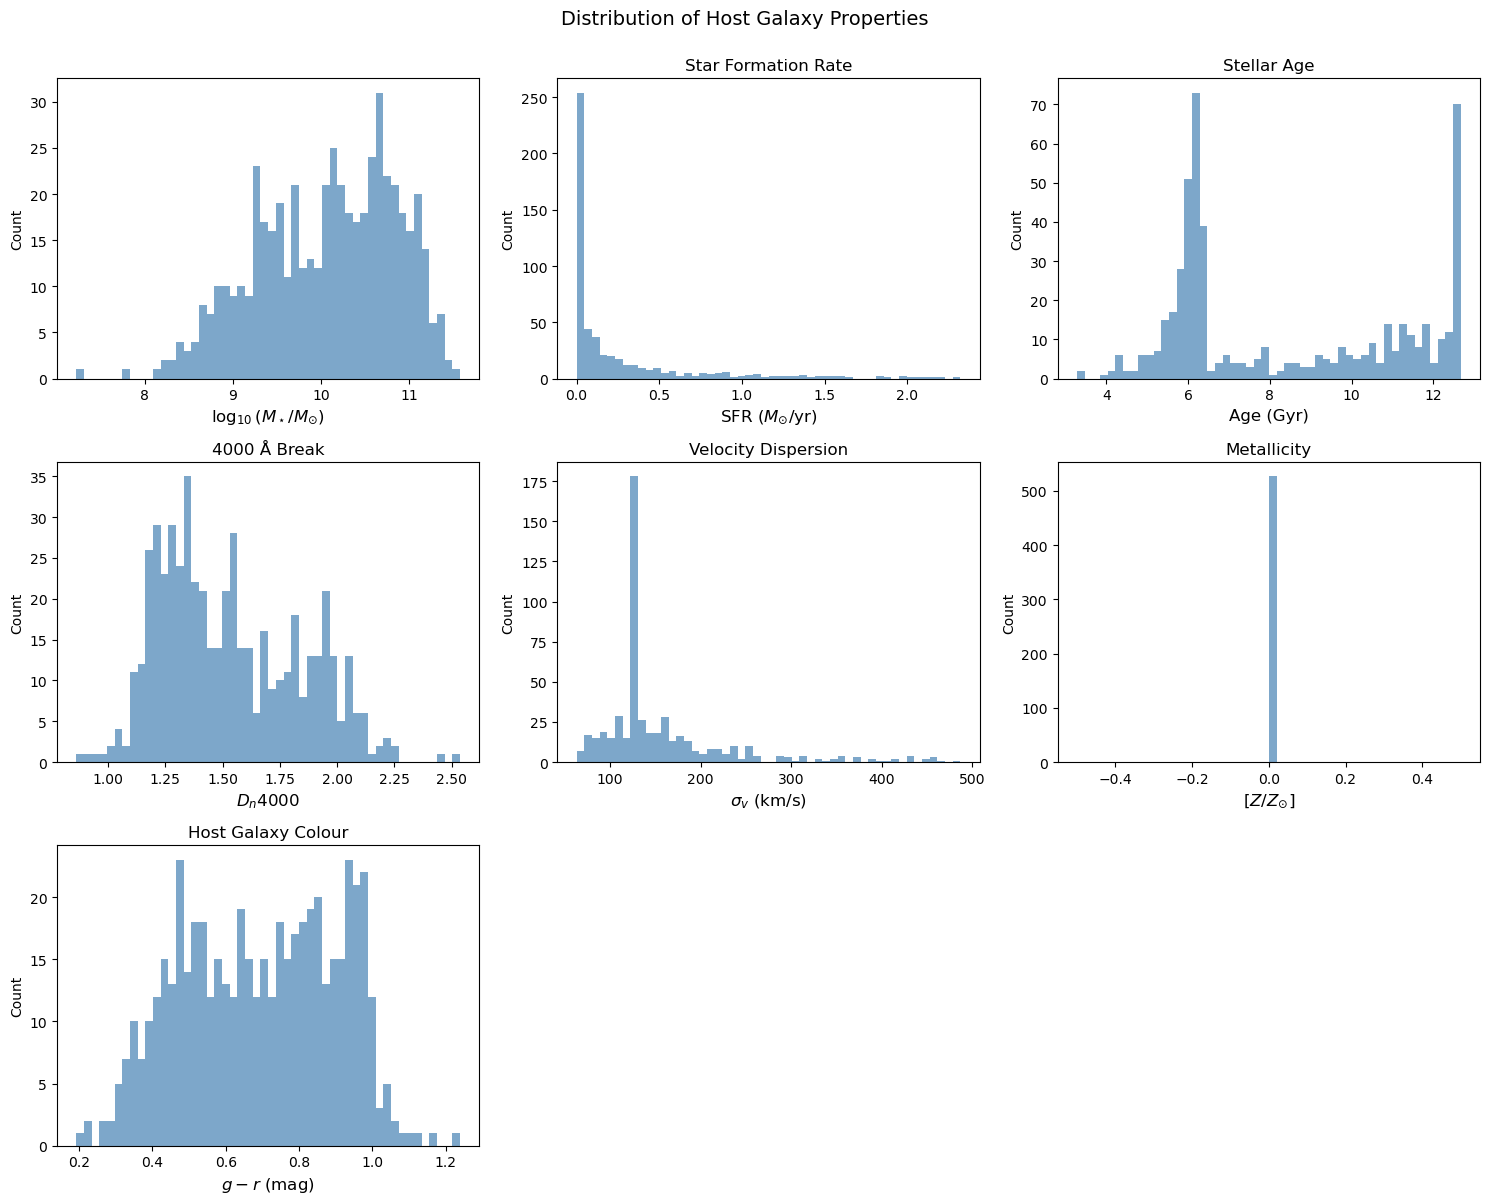

In [22]:
df["DESI_FASTSPEC_g_minus_r"] = df["DESI_FASTSPEC_ABSMAG01_SDSS_G"] - df["DESI_FASTSPEC_ABSMAG01_SDSS_R"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

ax = axes[0, 0]
ax.hist(df["DESI_FASTSPEC_LOGMSTAR"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$\log_{10}(M_\star / M_{\odot})$", fontsize=12)
ax.set_ylabel("Count")

ax = axes[0, 1]
ax.hist(df["DESI_FASTSPEC_SFR"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"SFR $(M_{\odot}/\mathrm{yr})$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Star Formation Rate")

ax = axes[0, 2]
ax.hist(df["DESI_FASTSPEC_AGE"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"Age (Gyr)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Stellar Age")

ax = axes[1, 0]
ax.hist(df["DESI_FASTSPEC_DN4000"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$D_n4000$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("4000 Å Break")

ax = axes[1, 1]
ax.hist(df["DESI_FASTSPEC_VDISP"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$\sigma_v$ (km/s)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Velocity Dispersion")

ax = axes[1, 2]
ax.hist(df["DESI_FASTSPEC_ZZSUN"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$[Z/Z_{\odot}]$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Metallicity")

ax = axes[2, 0]
ax.hist(df["DESI_FASTSPEC_g_minus_r"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$g - r$ (mag)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Host Galaxy Colour")

axes[2, 1].set_visible(False)
axes[2, 2].set_visible(False)

fig.suptitle("Distribution of Host Galaxy Properties", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

# Now Lets Get some Quality Cuts Defined and See What the Final Histograms Looks Like #

In [4]:
print(f"Before cuts: {len(df)}")

mask_sfr = df["DESI_FASTSPEC_SFR"] <= 2.5
print(f"SFR <= 2.5:    {mask_sfr.sum()} keep, {(~mask_sfr).sum()} dropped")
df = df[mask_sfr].reset_index(drop=True)

mask_dn4000 = df["DESI_FASTSPEC_DN4000"] >= 0.5
print(f"DN4000 >= 0.5: {mask_dn4000.sum()} keep, {(~mask_dn4000).sum()} dropped")
df = df[mask_dn4000].reset_index(drop=True)

mask_age = df["DESI_FASTSPEC_AGE"] >= 2
print(f"AGE >= 2 Gyr:  {mask_age.sum()} keep, {(~mask_age).sum()} dropped")
df = df[mask_age].reset_index(drop=True)

print(f"After all cuts: {len(df)}")

Before cuts: 540
SFR <= 2.5:    531 keep, 9 dropped
DN4000 >= 0.5: 529 keep, 2 dropped
AGE >= 2 Gyr:  527 keep, 2 dropped
After all cuts: 527


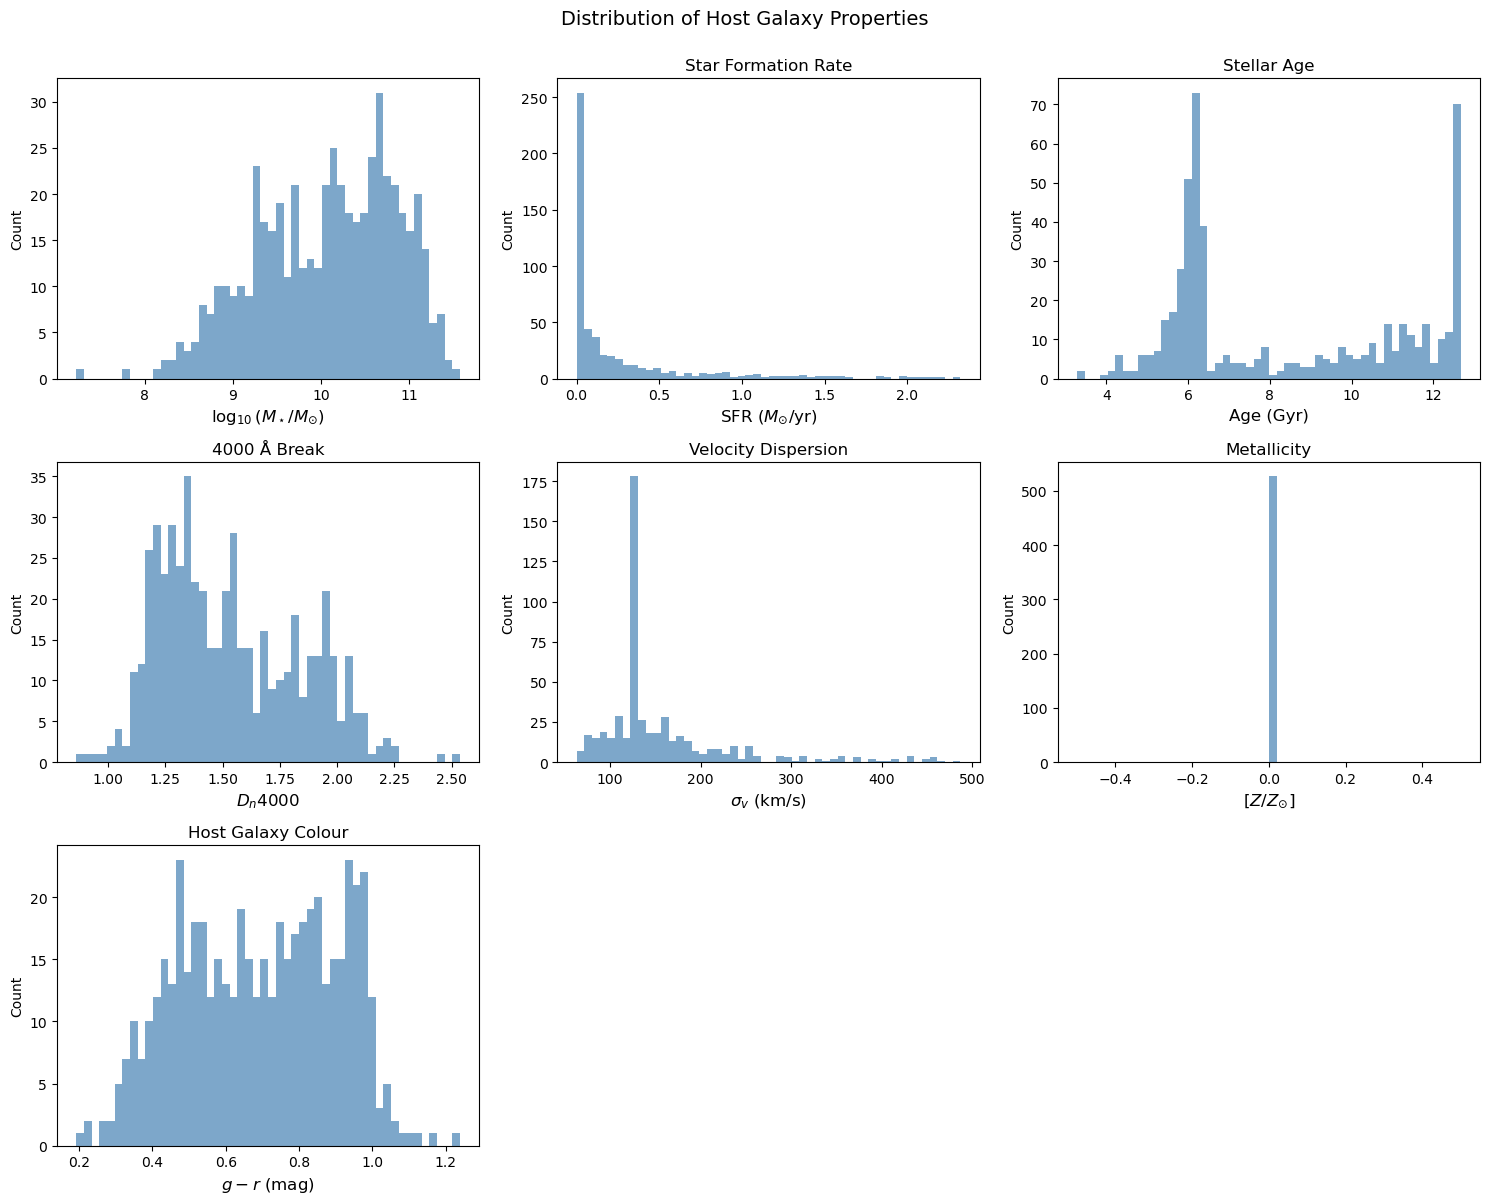

In [23]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

ax = axes[0, 0]
ax.hist(df["DESI_FASTSPEC_LOGMSTAR"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$\log_{10}(M_\star / M_{\odot})$", fontsize=12)
ax.set_ylabel("Count")

ax = axes[0, 1]
ax.hist(df["DESI_FASTSPEC_SFR"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"SFR $(M_{\odot}/\mathrm{yr})$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Star Formation Rate")

ax = axes[0, 2]
ax.hist(df["DESI_FASTSPEC_AGE"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"Age (Gyr)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Stellar Age")

ax = axes[1, 0]
ax.hist(df["DESI_FASTSPEC_DN4000"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$D_n4000$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("4000 Å Break")

ax = axes[1, 1]
ax.hist(df["DESI_FASTSPEC_VDISP"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$\sigma_v$ (km/s)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Velocity Dispersion")

ax = axes[1, 2]
ax.hist(df["DESI_FASTSPEC_ZZSUN"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$[Z/Z_{\odot}]$", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Metallicity")

ax = axes[2, 0]
ax.hist(df["DESI_FASTSPEC_g_minus_r"], bins=50, alpha=0.7, color="steelblue")
ax.set_xlabel(r"$g - r$ (mag)", fontsize=12)
ax.set_ylabel("Count")
ax.set_title("Host Galaxy Colour")

axes[2, 1].set_visible(False)
axes[2, 2].set_visible(False)

fig.suptitle("Distribution of Host Galaxy Properties", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

In [6]:
# Define the following global parameters:

alpha = 0.161
beta  = 3.05

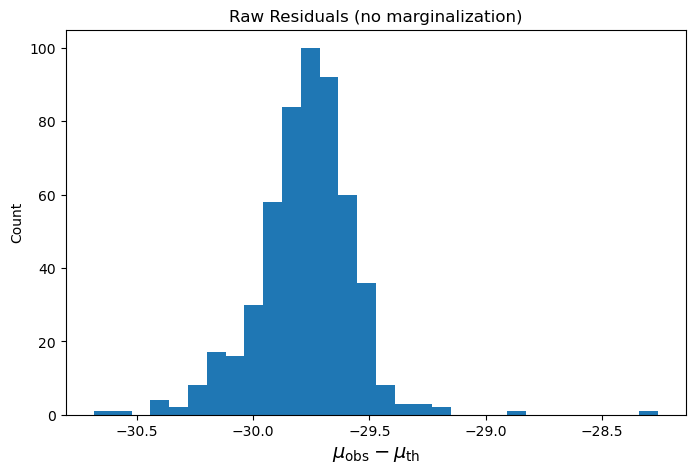

In [21]:
# Calculate the observed distance modulus for each supernova in the dataset: (not mass step corrected by design):
df["ZTF_mu_obs"] = -2.5 * np.log10(df["ZTF_x0"]) + alpha * df["ZTF_x1"] - beta * df["ZTF_c"]

# Define the following cosmology:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Evaluate the cosmology at the ZTF reported redshift. We are using the ZTF redshift instead of DESI
# b/c we're propagating the ZTF uncertainty and we want to keep everything in the same data set. 

mu_th = cosmo.distmod(df["ZTF_redshift"]).value
raw_residuals = df["ZTF_mu_obs"] - mu_th

plt.figure(figsize=(8, 5))
plt.hist(raw_residuals, bins=30)
plt.xlabel(r"$\mu_{\mathrm{obs}} - \mu_{\mathrm{th}}$", fontsize=14)
plt.ylabel("Count")
plt.title("Raw Residuals (no marginalization)")
plt.show()

# Now lets do the error Propagation from the SALT 2 Model Error #

General Form of the Error Propagation Formula for $y = f(x_1, x_2, \ldots, x_n)$

$
\sigma_y^2 =
\sum_{i=1}^{n}
\left(
\frac{\partial f}{\partial x_i}
\right)^2
\sigma_{x_i}^2
+
\sum_{i \ne j}
2\,
\frac{\partial f}{\partial x_i}
\frac{\partial f}{\partial x_j}
\mathrm{Cov}(x_i, x_j).
$

Using the standard error propagation formula:

$$
\sigma_{\mu,\text{obs}} = \sqrt{
\left(\frac{\partial \mu}{\partial x_0}\right)^2 \sigma_{x_0}^2
+\left(\frac{\partial \mu}{\partial x_1}\right)^2 \sigma_{x_1}^2
+\left(\frac{\partial \mu}{\partial c}\right)^2 \sigma_c^2
+ 2\left(\frac{\partial \mu}{\partial x_0}\frac{\partial \mu}{\partial x_1}\right)\mathrm{Cov}(x_0,x_1)
+ 2\left(\frac{\partial \mu}{\partial x_0}\frac{\partial \mu}{\partial c}\right)\mathrm{Cov}(x_0,c)
+ 2\left(\frac{\partial \mu}{\partial x_1}\frac{\partial \mu}{\partial c}\right)\mathrm{Cov}(x_1,c)
}
$$


where:

$
\frac{\partial\mu}{\partial x_0} = \frac{-2.5}{x_0\ln 10}
$

$
\frac{\partial\mu}{\partial x_1} = \alpha
$

$
\frac{\partial\mu}{\partial c} = -\beta
$


Reference: Bevington Ch. 3 Summary



In [8]:
LN10 = np.log(10)

# Partial derivatives of mu_obs w.r.t. SALT2 parameters

dmu_dx0 = -2.5 / (df["ZTF_x0"] * LN10)
dmu_dx1 = alpha
dmu_dc  = -beta

df["ZTF_sigma_mu"] = np.sqrt(
    dmu_dx0**2 * df["ZTF_x0_err"]**2
  + dmu_dx1**2 * df["ZTF_x1_err"]**2
  + dmu_dc**2  * df["ZTF_c_err"]**2
  + 2 * dmu_dx0 * dmu_dx1 * df["ZTF_cov_x0_x1"]
  + 2 * dmu_dx0 * dmu_dc  * df["ZTF_cov_x0_c"]
  + 2 * dmu_dx1 * dmu_dc  * df["ZTF_cov_x1_c"]
)


# Negative Log-Likelihood Minimization (Volume-Limited Sample - Always Remember to Volume Limit)

Since $\sigma_{\mathrm{int}}$ is a free parameter, we minimize the
negative log likelihood instead of plain $\chi^2$:

$-2\ln\mathcal{L} = \sum_i \left[\frac{\Delta\mu_i^2}{\sigma_{\mu,i}^2 + \sigma_{\mathrm{int}}^2} + \ln\left(\sigma_{\mu,i}^2 + \sigma_{\mathrm{int}}^2\right)\right]$

Please see appendix of this notebook for further explanation

In [9]:
# Define a volume limited data sample in order to avoid Malmquist bias.
df_vlim = df[df["ZTF_redshift"] < 0.06].copy()


# Define an array of theoretical distance moduli
# as applied to the volume limited sample.
mu_th_vlim = cosmo.distmod(df_vlim["ZTF_redshift"]).value


# DEFINE THE NEGATIVE LOG LIKELIHOOD FUNCTION AS ABOVE
# Function must be defined with a 1-D array of parameters 
# otherwise scipy.optimize.minimize will crash. Can't comma separate values. 
def neg_log_likelihood(params):

    script_M, sigma_int = params 

    mu_obs = -2.5 * np.log10(df_vlim["ZTF_x0"]) + alpha * df_vlim["ZTF_x1"] - beta * df_vlim["ZTF_c"] - script_M

    residuals = mu_obs - mu_th_vlim

    return np.sum(residuals**2 / (df_vlim["ZTF_sigma_mu"]**2 + sigma_int**2) + np.log(df_vlim["ZTF_sigma_mu"]**2 + sigma_int**2))


# Note this method requires first guesses so we will get some guesses for 
# Script M as 19.5 (absolute magnitude of SNIa -> will be a different quantitiy as we
# are marginalizing over Mb and the Hubble constant and the reported intrinsic scatter
# for the volume limited sample reported in Ginolin. 
result_vlim = minimize(neg_log_likelihood, [-19.5, 0.15])

print(result_vlim)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: -371.98273306433305
        x: [-2.975e+01  2.150e-01]
      nit: 25
      jac: [ 2.289e-05  6.104e-05]
 hess_inv: [[ 1.214e-04 -7.216e-06]
            [-7.216e-06  8.650e-05]]
     nfev: 114
     njev: 38


# Now that We Minimized the Negative Log Likelihood We Will Evaluate $\chi^2$ for the Volume Limited Sample of Our Data #

In [10]:
scriptM_vlim, sigma_int_vlim = result_vlim.x
print(f"script-M from Volume Limited Sample  = " + str(scriptM_vlim))
print(f"sigma_int = " + str(sigma_int_vlim))

df_vlim["residual"] = (-2.5 * np.log10(df_vlim["ZTF_x0"]) + alpha * df_vlim["ZTF_x1"] - beta * df_vlim["ZTF_c"] - scriptM_vlim) - mu_th_vlim
df_vlim["sigma_total"] = np.sqrt(df_vlim["ZTF_sigma_mu"]**2 + sigma_int_vlim**2)

chi2 = np.sum(df_vlim["residual"]**2 / df_vlim["sigma_total"]**2)
print(f"chi2/dof = {chi2 / (len(df_vlim) - 2):.2f}")

script-M from Volume Limited Sample  = -29.75349298781245
sigma_int = 0.21495456670776544
chi2/dof = 1.05


# Now that We Minimized the Negative Log Likelihood for the Volume Limited Sample We are Ready to compute the Residuals #

/var/folders/71/hv72gkrs7g59ty6664549kjr0000gr/T/ipykernel_91982/2337485234.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(sim_z, mu_th_plot, "r-", label="Theoretical Distance Modulus", color = "orange", linewidth = 5)


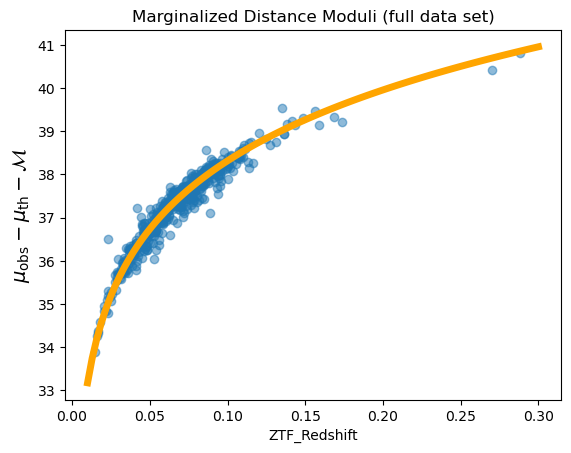

In [11]:
# Note we are applying this script-M to the full data set.
# We are just borrowing scriptM_vlim from the volume limited sample.
# "ZTF_mu_obs" 
marginalized_distance_modulus = df["ZTF_mu_obs"] - scriptM_vlim

# Data necessary froom the Theory Plot
sim_z = np.linspace(0.01, 0.3, 100)
mu_th_plot = cosmo.distmod(sim_z).value


plt.plot(df["ZTF_redshift"], marginalized_distance_modulus, "o", alpha=0.5)
plt.plot(sim_z, mu_th_plot, "r-", label="Theoretical Distance Modulus", color = "orange", linewidth = 5)
plt.xlabel("ZTF_Redshift")
plt.ylabel(r"$\mu_{\mathrm{obs}} - \mu_{\mathrm{th}} - \mathcal{M}$", fontsize=14)
plt.title("Marginalized Distance Moduli (full data set)")
plt.show()

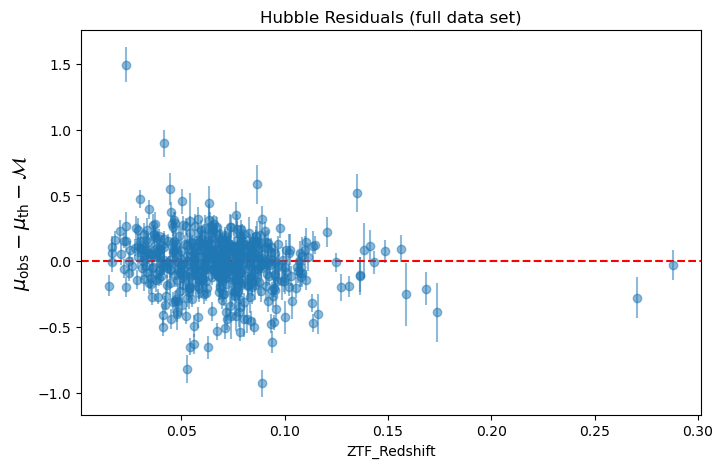

In [12]:
residuals = df["ZTF_mu_obs"] - cosmo.distmod(df["ZTF_redshift"]).value - scriptM_vlim
plt.figure(figsize=(8, 5))
plt.errorbar(df["ZTF_redshift"], residuals, yerr=df["ZTF_sigma_mu"], fmt="o", alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("ZTF_Redshift")
plt.ylabel(r"$\mu_{\mathrm{obs}} - \mu_{\mathrm{th}} - \mathcal{M}$", fontsize=14)
plt.title("Hubble Residuals (full data set)")
plt.show()

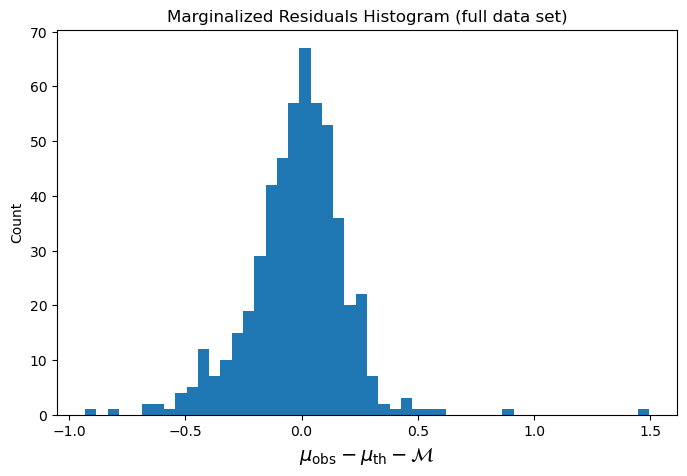

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50)
plt.xlabel(r"$\mu_{\mathrm{obs}} - \mu_{\mathrm{th}} - \mathcal{M}$", fontsize=14)
plt.ylabel("Count")
plt.title("Marginalized Residuals Histogram (full data set)")
plt.show()


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 527 entries, 0 to 526
Data columns (total 68 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ZTF_Unnamed: 0                    527 non-null    float64
 1   ztfname                           527 non-null    object 
 2   ZTF_redshift                      527 non-null    float64
 3   ZTF_redshift_err                  527 non-null    float64
 4   ZTF_source                        527 non-null    object 
 5   ZTF_t0                            527 non-null    float64
 6   ZTF_x0                            527 non-null    float64
 7   ZTF_x1                            527 non-null    float64
 8   ZTF_c                             527 non-null    float64
 9   ZTF_t0_err                        527 non-null    float64
 10  ZTF_x0_err                        527 non-null    float64
 11  ZTF_x1_err                        527 non-null    float64
 12  ZTF_c_er

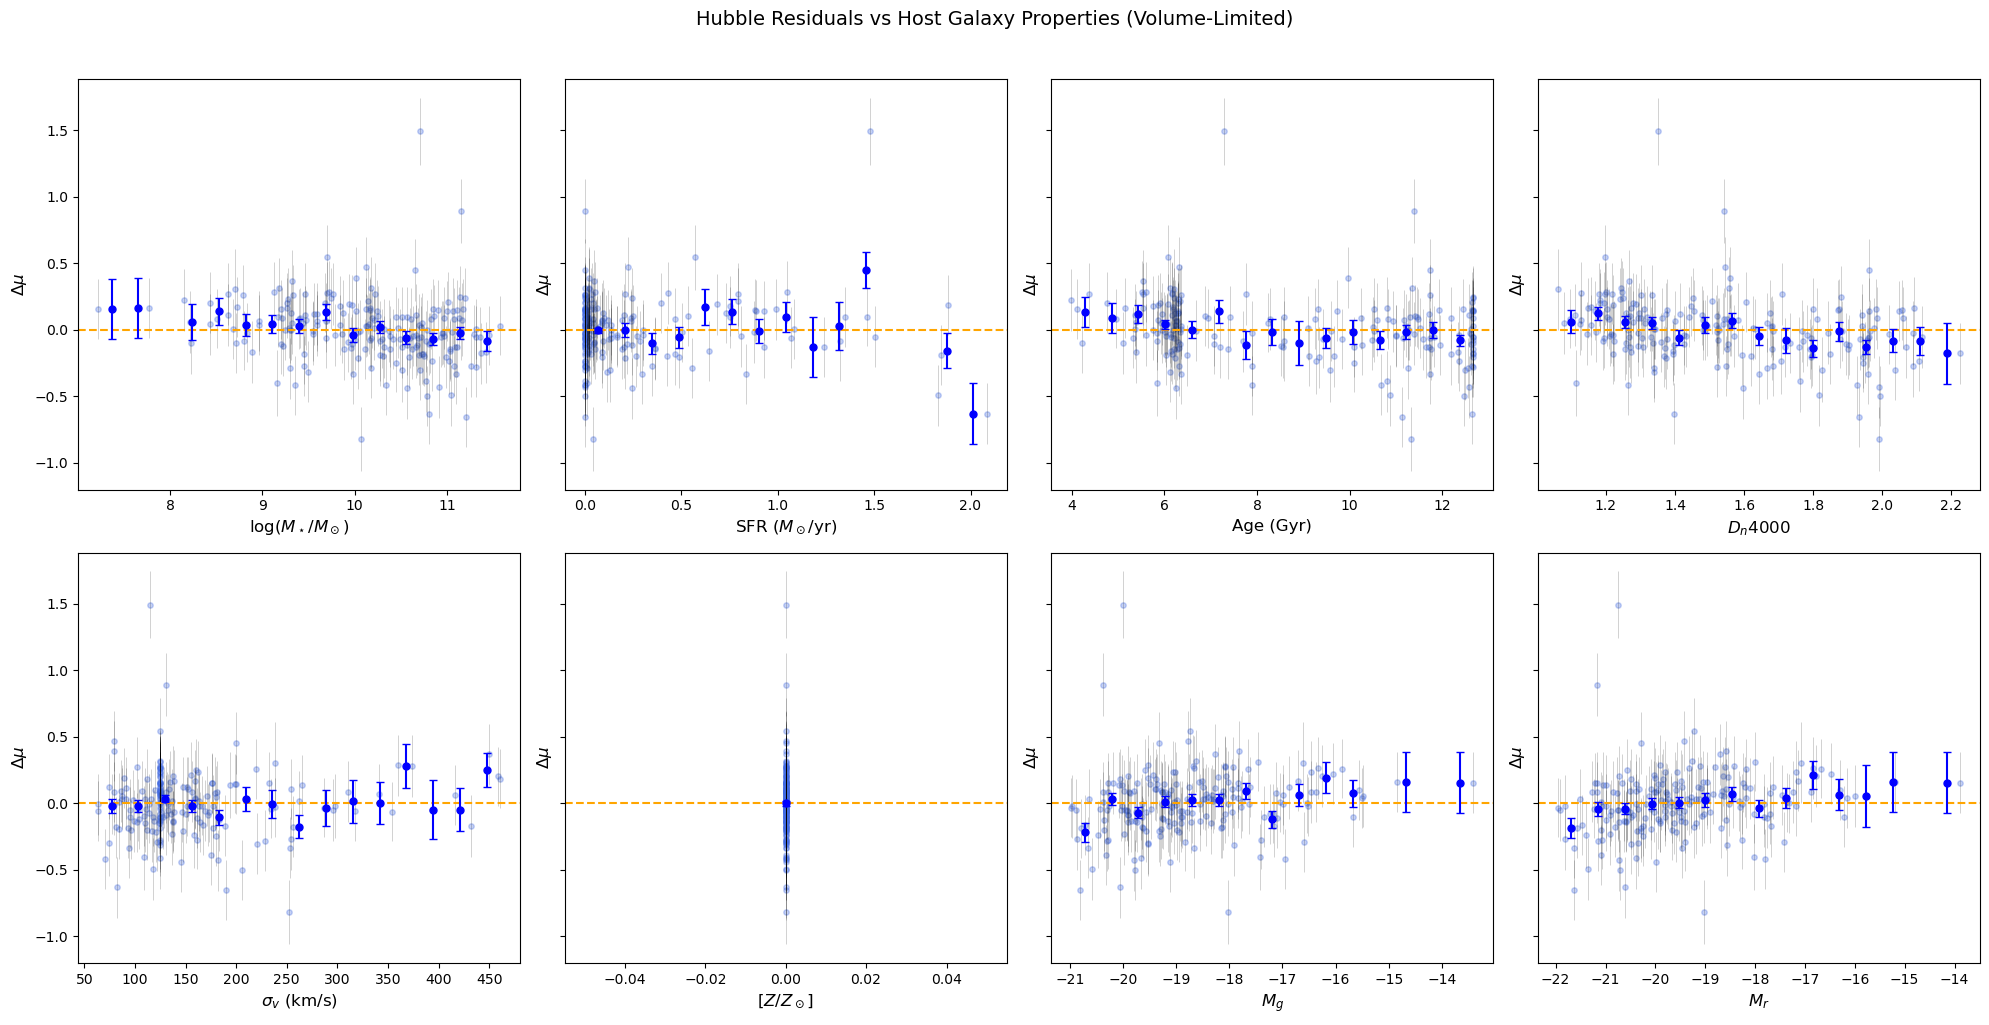

In [ ]:
from scipy.stats import binned_statistic

def scatter_with_errors(ax, xcol, data, nbins=15):
    x = data[xcol].values
    y = data["residual"].values
    yerr = data["sigma_total"].values

    ax.scatter(x, y, s=15, alpha=0.3, color="royalblue", zorder=1)
    ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor="black",
                elinewidth=0.5, alpha=0.25, zorder=2)
    ax.axhline(0, linestyle="--", color="orange")

    _, bin_edges, binnumber = binned_statistic(x, x, statistic="count", bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    binned_y = []
    binned_yerr = []
    for i in range(1, len(bin_edges)):
        in_bin = binnumber == i
        if np.sum(in_bin) == 0:
            binned_y.append(np.nan)
            binned_yerr.append(np.nan)
            continue
        y_bin = y[in_bin]
        err_bin = yerr[in_bin]
        w = 1.0 / (err_bin**2)
        binned_y.append(np.sum(w * y_bin) / np.sum(w))
        binned_yerr.append(1.0 / np.sqrt(np.sum(w)))
    
    binned_y = np.array(binned_y)
    binned_yerr = np.array(binned_yerr)
    ok = np.isfinite(binned_y) & np.isfinite(binned_yerr)
    ax.errorbar(bin_centers[ok], binned_y[ok], yerr=binned_yerr[ok],
                fmt="o", color="blue", markersize=5, capsize=3, zorder=5)

# Make sure residual and sigma_total exist
df_vlim["residual"] = (-2.5 * np.log10(df_vlim["ZTF_x0"])
                        + alpha * df_vlim["ZTF_x1"]
                        - beta * df_vlim["ZTF_c"]
                        - scriptM_vlim) - mu_th_vlim
df_vlim["sigma_total"] = np.sqrt(df_vlim["ZTF_sigma_mu"]**2 + sigma_int_vlim**2)

# Plot each host property
features = {
    "DESI_FASTSPEC_LOGMSTAR": r"$\log(M_\star / M_\odot)$",
    "DESI_FASTSPEC_SFR": r"SFR $(M_\odot / \mathrm{yr})$",
    "DESI_FASTSPEC_AGE": r"Age (Gyr)",
    "DESI_FASTSPEC_DN4000": r"$D_n4000$",
    "DESI_FASTSPEC_VDISP": r"$\sigma_v$ (km/s)",
    "DESI_FASTSPEC_ZZSUN": r"$[Z/Z_\odot]$",
    "DESI_FASTSPEC_ABSMAG01_SDSS_G": r"$M_g$",
    "DESI_FASTSPEC_ABSMAG01_SDSS_R": r"$M_r$",
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=True)

for ax, (col, label) in zip(axes.flatten(), features.items()):
    scatter_with_errors(ax, col, df_vlim, nbins=15)
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel(r"$\Delta\mu$", fontsize=12)

fig.suptitle("Hubble Residuals vs Host Galaxy Properties (Volume-Limited)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

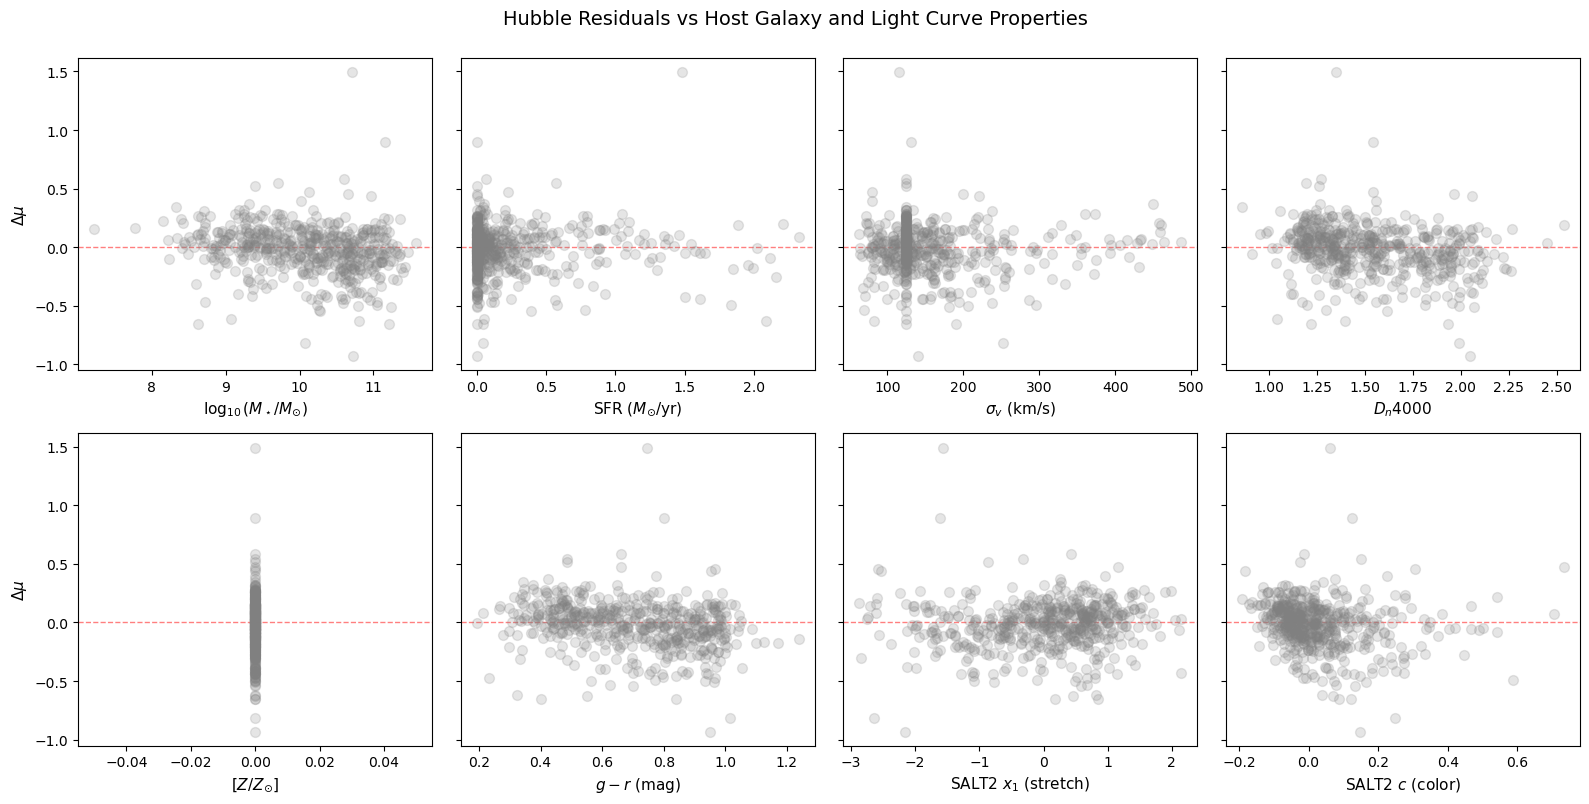

In [17]:

# --------------------------------------
# Create g - r host-galaxy color
# --------------------------------------
df["DESI_FASTSPEC_g_minus_r"] = df["DESI_FASTSPEC_ABSMAG01_SDSS_G"] - df["DESI_FASTSPEC_ABSMAG01_SDSS_R"]


# ****************************************************************************
# ----------------------------------------------------------------------------
# Set up 2x4 grid - RESIDUALS vs HOST GALAXY AND LIGHT CURVE PROPERTIES
# ----------------------------------------------------------------------------
# ****************************************************************************

# Compute full dataset residuals for plotting
df["residual"] = (-2.5 * np.log10(df["ZTF_x0"]) 
                  + alpha * df["ZTF_x1"] 
                  - beta * df["ZTF_c"] 
                  - scriptM_vlim) - cosmo.distmod(df["ZTF_redshift"]).value

# Add sigma for error bars
df["sigma_mu_meas"] = np.sqrt(
    (-2.5 / (df["ZTF_x0"] * LN10))**2 * df["ZTF_x0_err"]**2
    + alpha**2 * df["ZTF_x1_err"]**2
    + beta**2 * df["ZTF_c_err"]**2
    + 2 * (-2.5 / (df["ZTF_x0"] * LN10)) * alpha * df["ZTF_cov_x0_x1"]
    + 2 * (-2.5 / (df["ZTF_x0"] * LN10)) * (-beta) * df["ZTF_cov_x0_c"]
    + 2 * alpha * (-beta) * df["ZTF_cov_x1_c"]
)

# global number of bins
nbins = 10

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.flatten()

point_kwargs = dict(alpha=0.2, s=50, color="grey", zorder=3)   

# --------------------------------------
# 1) LOGMSTAR
# --------------------------------------
ax = axes[0]

mask = np.isfinite(df["DESI_FASTSPEC_LOGMSTAR"]) & np.isfinite(df["residual"])
ax.scatter(df.loc[mask, "DESI_FASTSPEC_LOGMSTAR"], df.loc[mask, "residual"], **point_kwargs)

ax.set_xlabel(r"$\log_{10}(M_\star / M_{\odot})$", fontsize=11)
ax.set_ylabel(r"$\Delta \mu$", fontsize=11)
ax.axhline(0, color="red", linestyle="--", alpha=0.5, linewidth=1)

# --------------------------------------
# 2) SFR
# --------------------------------------
ax = axes[1]

mask = np.isfinite(df["DESI_FASTSPEC_SFR"]) & np.isfinite(df["residual"])
ax.scatter(df.loc[mask, "DESI_FASTSPEC_SFR"], df.loc[mask, "residual"], **point_kwargs)

ax.set_xlabel(r"SFR $(M_{\odot}/\mathrm{yr})$", fontsize=11)
ax.axhline(0, color="red", linestyle="--", alpha=0.5, linewidth=1)

# --------------------------------------
# 3) VDISP
# --------------------------------------
ax = axes[2]

mask = np.isfinite(df["DESI_FASTSPEC_VDISP"]) & np.isfinite(df["residual"])
ax.scatter(df.loc[mask, "DESI_FASTSPEC_VDISP"], df.loc[mask, "residual"], **point_kwargs)

ax.set_xlabel(r"$\sigma_v$ (km/s)", fontsize=11)
ax.axhline(0, color="red", linestyle="--", alpha=0.5, linewidth=1)

# --------------------------------------
# 4) DN4000
# --------------------------------------
ax = axes[3]

mask = np.isfinite(df["DESI_FASTSPEC_DN4000"]) & np.isfinite(df["residual"])
ax.scatter(df.loc[mask, "DESI_FASTSPEC_DN4000"], df.loc[mask, "residual"], **point_kwargs)

ax.set_xlabel(r"$D_n4000$", fontsize=11)
ax.axhline(0, color="red", linestyle="--", alpha=0.5, linewidth=1)

# --------------------------------------
# 5) METALLICITY
# --------------------------------------
ax = axes[4]

mask = np.isfinite(df["DESI_FASTSPEC_ZZSUN"]) & np.isfinite(df["residual"])
ax.scatter(df.loc[mask, "DESI_FASTSPEC_ZZSUN"], df.loc[mask, "residual"], **point_kwargs)

ax.set_xlabel(r"$[Z/Z_{\odot}]$", fontsize=11)
ax.set_ylabel(r"$\Delta \mu$", fontsize=11)
ax.axhline(0, color="red", linestyle="--", alpha=0.5, linewidth=1)

# --------------------------------------
# 6) SDSS g - r color
# --------------------------------------
ax = axes[5]

mask = np.isfinite(df["DESI_FASTSPEC_g_minus_r"]) & np.isfinite(df["residual"])
ax.scatter(df.loc[mask, "DESI_FASTSPEC_g_minus_r"], df.loc[mask, "residual"], **point_kwargs)

ax.set_xlabel(r"$g - r$ (mag)", fontsize=11)
ax.axhline(0, color="red", linestyle="--", alpha=0.5, linewidth=1)

# --------------------------------------
# 7) x1 (SALT2 stretch parameter)
# --------------------------------------
ax = axes[6]

mask = np.isfinite(df["ZTF_x1"]) & np.isfinite(df["residual"])
ax.scatter(df.loc[mask, "ZTF_x1"], df.loc[mask, "residual"], **point_kwargs)

ax.set_xlabel("SALT2 $x_1$ (stretch)", fontsize=11)
ax.axhline(0, color="red", linestyle="--", alpha=0.5, linewidth=1)

# --------------------------------------
# 8) c (SALT2 color parameter)
# --------------------------------------
ax = axes[7]

mask = np.isfinite(df["ZTF_c"]) & np.isfinite(df["residual"])
ax.scatter(df.loc[mask, "ZTF_c"], df.loc[mask, "residual"], **point_kwargs)

ax.set_xlabel("SALT2 $c$ (color)", fontsize=11)
ax.axhline(0, color="red", linestyle="--", alpha=0.5, linewidth=1)

# --------------------------------------
# Global cosmetics and title
# --------------------------------------
fig.suptitle("Hubble Residuals vs Host Galaxy and Light Curve Properties", fontsize=14, y=1.00)
fig.tight_layout()
plt.show()
